# Flood Segmentation Model — Fine-tuning Prithvi-EO-1.0-100M on Sen1Floods11

**Purpose:** train the flood/water segmentation model used by the Pakistan Flood Risk Monitor backend (see `IMPLEMENTATION_PLAN.md`).

**What this notebook does NOT do:** it does not use any Pakistan-specific imagery — Sen1Floods11 is a global benchmark (11 flood events worldwide, no Pakistan data in it). This notebook produces a general-purpose flood/water segmentation model. Applying it to live Pakistan Sentinel imagery happens later, in the backend pipeline, not here.

**Environment note:** built for Kaggle (free T4 GPU). Enable GPU under Settings → Accelerator before running.

**Update (verified against live sources, Sept 2026):** the first version of this notebook had two spots flagged "check before running" — both were checked, and both needed a real fix, not just a filename tweak:
- The Hugging Face mirror in section 3 (`harshinde/sen1floods11`) doesn't just have a new name — it's not loadable via `datasets.load_dataset()` at all (its dataset card declares a `Mask` feature type the `datasets` library doesn't recognize, confirmed via `datasets-server.huggingface.co`). Section 3 now downloads directly from the original public GCS bucket over plain HTTPS instead (no `gsutil`/auth needed — verified working), using the paper's own official train/valid/test split CSVs.
- The Prithvi repo moved to `ibm-nasa-geospatial/Prithvi-EO-1.0-100M` and its config file is `config.yaml`, not `Prithvi_100M_config.yaml`. More importantly, the repo now ships its actual model-definition code (`prithvi_mae.py`) alongside the checkpoint — section 5 downloads and imports that directly and builds the real `PrithviViT` encoder class from it, instead of a guessed placeholder wrapper.

Both fixes are verified against the live checkpoint/config/dataset shapes as of when this was written — if something upstream moves again, the error will point at the same two sections.

**Outputs this notebook produces (download these before leaving Kaggle):**
- `flood_segmentation_model.pt` — fine-tuned weights (whichever of U-Net/Prithvi scores higher, chosen automatically in section 9)
- `model_config.json` — band order, real dataset-computed normalization stats, input chip size
- `metrics.json` — mIoU, F1, precision, recall on the test split, for both models
- `sample_predictions.png` — a few input/ground-truth/prediction triptychs, for your README/LinkedIn post


**Update 2 (benchmarked against the official Prithvi/Sen1Floods11 fine-tune, Sept 2026):** the first real run of this notebook worked end-to-end (25 epochs, both models, no errors -- see the run this replaced) and got U-Net mIoU 0.874 / Prithvi mIoU 0.822. Before calling that final, it was checked against the actual published benchmark for this exact model on this exact dataset: `ibm-nasa-geospatial/Prithvi-100M-sen1floods11` reports **mIoU 88.68%, water IoU 80.46%** after 100 epochs. Our Prithvi fine-tune was ~11 points behind on water IoU -- a real gap, not noise.

Pulling NASA-IMPACT's actual training config (`Prithvi-EO-2.0/configs/sen1floods11.yaml`) turned up concrete, fixable causes, not a fundamentally different setup:

| | Official recipe | This notebook (v1) |
|---|---|---|
| Learning rate | 5e-5 | 3e-4 (6x too high for fine-tuning a pretrained ViT) |
| LR schedule | CosineAnnealingLR, T_max=50 | none (flat LR) |
| Epochs | 50 | 25 |
| Batch size | 16 | 8 |
| Augmentation | horizontal + vertical flip | none |
| Decoder input | 4 transformer layers (indices 2, 5, 8, 11) fused via UperNet | only the last layer, plain conv decoder |

Section 5 below now uses the corrected LR/schedule/epochs/batch size/augmentation directly, and fuses the same 4 transformer layers the official recipe selects -- through a lighter concatenation + conv decoder rather than a full UperNet reimplementation (matches this notebook's stated goal of staying simple enough to explain every part of it, not matching every implementation detail of mmsegmentation). Expect this to close most, not necessarily all, of the gap to the official number -- report whatever you actually get, not this expectation.


**Update 3 (the v2 hyperparameter fixes didn't move the needle -- diagnosed why):** after Update 2's
LR/schedule/epoch/batch-size/augmentation fixes, a real rerun came back at mIoU 0.824 / water IoU 0.698
-- essentially unchanged from v1's 0.822 / 0.695. The printed per-epoch log confirmed every fix actually
took effect (LR visibly decayed 5e-05 -> 0 via the cosine schedule, trainable param count matched the
wider multi-layer decoder, 50 epochs ran) -- and the model **plateaued by epoch ~25**, meaning it wasn't
undertrained. That rules out training hyperparameters as the bottleneck and points at the decoder.

Pulling the official config's `model` block (not just its optimizer settings) confirmed it: the real
decoder is `UperNetDecoder` with `necks: [SelectIndices([2,5,8,11]), ReshapeTokensToImage]` --
i.e. an actual multi-resolution feature pyramid (Xiao et al. 2018's FPN + Pyramid Pooling Module),
not four same-resolution layers concatenated and convolved, which is what section 5 was doing. A
plain ViT produces every layer's tokens at the *same* spatial resolution (no built-in pyramid the
way a CNN backbone has); UperNet's neck artificially builds one by resizing each selected layer to
a different target scale, and its PPM adds global context pooling at the coarsest scale before a
top-down fusion pass. That structural difference -- not the learning rate -- is the more likely
source of the remaining gap to the official 0.887 mIoU / 0.805 water IoU.

Section 5 below now implements this directly: `UperNetLiteDecoder` builds a real 4-scale pyramid
(28/14/7/4), runs a Pyramid Pooling Module (bins 1/2/3/6) on the coarsest level, and fuses top-down
with lateral connections and smoothing convs -- the same two ingredients (FPN + PPM) as the actual
UperNet, sized down rather than functionally simplified. Verified locally (forward + backward pass,
zero parameters with dead gradients) before being written in here.


**Update 4 (the decoder rewrite didn't move it either -- found the actual shared cause):**
v3's real UperNet-lite decoder came back at mIoU 0.821 / water IoU 0.693 -- flat with v1 (0.822/0.695)
and v2 (0.824/0.698). Three different, individually-verified fixes, three null results. That's strong
evidence the bottleneck isn't in the Prithvi-specific code at all -- since U-Net was never touched
across any of these changes and its own numbers (0.874 / 0.870 / 0.865 mIoU across the three runs)
are just as flat.

Checked an independent, peer-reviewed reproduction of this exact benchmark (SIGSPATIAL 2023,
"Assessment of a new GeoAI foundation model for flood inundation mapping",
https://arxiv.org/abs/2309.14500) instead of only IBM's own number. Two findings:
1. Their run also found **U-Net (mIoU 90.80) beating Prithvi (89.59)** on this dataset -- the same
   direction as every one of our runs. That part of the result is a real, published pattern on this
   benchmark, not a bug in this pipeline.
2. Both their numbers sit around 88-91% mIoU -- for *both* architectures -- while ours sit around
   82-87% for *both*. A gap that shows up on both models equally, and that no per-model change has
   touched, points at something shared in the data pipeline, not either model's code.

Their config specifies **"Cropped image size: 244"** [sic, 224] -- a random *crop* of a 224x224 patch
at full native resolution, not what this notebook has done from the start: *resizing* the whole
512x512 chip down to 224x224. That downsampling blurs exactly the kind of detail (thin river
channels, small ponds) that `sample_predictions.png` showed being under-detected across every run
so far, and it would affect every model reading from `FloodSegDataset` identically -- consistent
with everything observed above.

Section 4 below now trains on random 224x224 crops at native resolution (with a deterministic
center-crop for the fast per-epoch validation used only to pick the best checkpoint) and evaluates
on the *full* 512x512 test images via tiled (sliding-window) inference -- pad to 672x672, run the
model on a non-overlapping 3x3 grid of tiles, stitch the predictions back, crop to the original
512x512 -- so the reported test metrics score the whole labeled image, not a single crop of it.
Verified locally: the pad/tile/stitch/crop round-trip reconstructs a test array exactly, and a dummy
model run through the same code path produces a correctly-shaped, correctly-aligned prediction.


In [1]:
# 1. Install dependencies
!pip install -q rasterio segmentation-models-pytorch huggingface_hub timm einops


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.9 MB/s eta 0:00:0000:010:01


In [2]:
# 2. Imports & config
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CONFIG = {
    "chip_size": 224,          # Prithvi's native patch grid (patch_size=16, img_size=224) -- verified against its config.yaml
    "bands": ["blue", "green", "red", "nir_narrow", "swir1", "swir2"],  # verified against Prithvi's model card AND Sen1Floods11's S2 band table (see section 4)
    "batch_size": 16,          # matches NASA-IMPACT's official sen1floods11.yaml (was 8 in the first pass)
    "num_classes": 2,          # 0 = no water, 1 = water/flood (dataset also has a "no-data/cloud" label we mask out of the loss)
    "augment": True,           # random h-flip/v-flip on the train split only -- matches the official recipe; satellite imagery has no canonical orientation, so this is safe, label-preserving augmentation

    # U-Net baseline -- unchanged from the first pass, which already scored close to the
    # official Prithvi benchmark (0.874 mIoU vs. their 0.887), so there's no evidence this needs fixing.
    "unet_epochs": 25,
    "unet_lr": 3e-4,

    # Prithvi fine-tune -- corrected against NASA-IMPACT's actual published training config
    # (Prithvi-EO-2.0/configs/sen1floods11.yaml) after the first pass under-performed their
    # official benchmark by ~11 points of water IoU. See the markdown note in section 0/5.
    "prithvi_epochs": 50,          # was 25
    "prithvi_lr": 5e-5,            # was 3e-4 -- 6x too aggressive for fine-tuning a pretrained ViT
    "prithvi_weight_decay": 0.05,  # was AdamW's PyTorch default (0.01)
    "prithvi_layer_indices": (2, 5, 8, 11),  # which of the 12 transformer blocks feed the decoder -- same layers the official UperNet head uses
    "freeze_prithvi_backbone": False,  # True = linear-probe (fast, less prone to overfitting on 252 train chips); False = full fine-tune
}


Device: cuda


## 3. Download Sen1Floods11

Downloads the hand-labeled subset directly from the original public GCS bucket (`gs://sen1floods11`) over plain HTTPS — no `gsutil`, no GCP auth, no Hugging Face account needed; the bucket allows anonymous reads (verified). Uses the dataset's own official `flood_train_data.csv` / `flood_valid_data.csv` / `flood_test_data.csv` split files (431 chips total: 252/89/90) so results are directly comparable to the Sen1Floods11 paper's numbers, rather than an arbitrary re-split.

Pulls the `S2Hand` (13-band Sentinel-2 L1C, verified band order below) and `LabelHand` (ground-truth mask) layers for each chip — not `S1Hand` (SAR), even though the split CSVs list `*_S1Hand.tif` filenames (chip IDs are shared across layers; this swaps the suffix).


In [3]:
# 3. Download the hand-labeled Sen1Floods11 chips (S2Hand + LabelHand) for all three splits.
import concurrent.futures
import csv
import io
import urllib.request

GCS_BASE = "https://storage.googleapis.com/sen1floods11/v1.1"
SPLIT_URLS = {
    "train": f"{GCS_BASE}/splits/flood_handlabeled/flood_train_data.csv",
    "validation": f"{GCS_BASE}/splits/flood_handlabeled/flood_valid_data.csv",
    "test": f"{GCS_BASE}/splits/flood_handlabeled/flood_test_data.csv",
}
DATA_DIR = "/kaggle/working/sen1floods11"
os.makedirs(f"{DATA_DIR}/S2Hand", exist_ok=True)
os.makedirs(f"{DATA_DIR}/LabelHand", exist_ok=True)


def fetch_url(url: str, retries: int = 3) -> bytes:
    last_err = None
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=60) as resp:
                return resp.read()
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to fetch {url} after {retries} attempts: {last_err}")


def chip_ids_for_split(split_url: str) -> list:
    text = fetch_url(split_url).decode("utf-8")
    reader = csv.reader(io.StringIO(text))
    # each row: EVENT_CHIPID_S1Hand.tif, EVENT_CHIPID_LabelHand.tif — we want the shared EVENT_CHIPID prefix
    return [row[0].replace("_S1Hand.tif", "") for row in reader if row]


def download_chip(chip_id: str) -> str:
    s2_path = f"{DATA_DIR}/S2Hand/{chip_id}_S2Hand.tif"
    label_path = f"{DATA_DIR}/LabelHand/{chip_id}_LabelHand.tif"
    if not os.path.exists(s2_path):
        with open(s2_path, "wb") as f:
            f.write(fetch_url(f"{GCS_BASE}/data/flood_events/HandLabeled/S2Hand/{chip_id}_S2Hand.tif"))
    if not os.path.exists(label_path):
        with open(label_path, "wb") as f:
            f.write(fetch_url(f"{GCS_BASE}/data/flood_events/HandLabeled/LabelHand/{chip_id}_LabelHand.tif"))
    return chip_id


split_chip_ids = {split: chip_ids_for_split(url) for split, url in SPLIT_URLS.items()}
for split, ids in split_chip_ids.items():
    print(f"{split}: {len(ids)} chips")

all_chip_ids = [cid for ids in split_chip_ids.values() for cid in ids]
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as pool:
    for i, _ in enumerate(pool.map(download_chip, all_chip_ids)):
        if (i + 1) % 50 == 0 or (i + 1) == len(all_chip_ids):
            print(f"Downloaded {i + 1}/{len(all_chip_ids)} chips...")

print(f"Done. {len(all_chip_ids)} chip pairs (S2Hand + LabelHand) in {DATA_DIR}")


train: 252 chips
validation: 89 chips
test: 90 chips
Downloaded 50/431 chips...
Downloaded 100/431 chips...
Downloaded 150/431 chips...
Downloaded 200/431 chips...
Downloaded 250/431 chips...
Downloaded 300/431 chips...
Downloaded 350/431 chips...
Downloaded 400/431 chips...
Downloaded 431/431 chips...
Done. 431 chip pairs (S2Hand + LabelHand) in /kaggle/working/sen1floods11


## 4. Dataset class

Reads the downloaded GeoTIFFs directly with `rasterio`. `S2Hand` is a 13-band raw Sentinel-2 L1C stack; per Sen1Floods11's own docs, band indices (0-based) are `0:B1(Coastal) 1:B2(Blue) 2:B3(Green) 3:B4(Red) 4:B5(RedEdge1) 5:B6(RedEdge2) 6:B7(RedEdge3) 7:B8(NIR) 8:B8A(NarrowNIR) 9:B9(WaterVapor) 10:B10(Cirrus) 11:B11(SWIR1) 12:B12(SWIR2)` -- verified by downloading and inspecting a sample chip. `CONFIG["bands"]` (blue, green, red, nir_narrow, swir1, swir2) maps to 0-based indices `[1, 2, 3, 8, 11, 12]`, i.e. rasterio's 1-based band numbers `[2, 3, 4, 9, 12, 13]`. This is the same 6-band set Prithvi was pretrained on (HLS's own B02-B07 naming for the same physical bands -- see section 5).

`LabelHand` is a single-band mask: `-1` no-data, `0` no water, `1` water (verified).

Also computes **real** dataset-wide per-band mean/std over the full-resolution training chips (not a resized or cropped version -- statistics shouldn't depend on that choice) -- this is what gets saved into `model_config.json` in section 9, since the backend must normalize live imagery the same way at inference time.

**Crop, don't resize (v4):** chips are natively 512x512; `CONFIG["chip_size"]=224` is now used as a
*crop* size, not a resize target -- see the section 0 changelog for why. `FloodSegDataset` supports
three modes:
- `"train"`: a random 224x224 crop each call, plus h/v flip augmentation -- full native resolution, and effectively more training diversity per epoch since every image has many possible crop positions.
- `"eval_center"`: a single deterministic center 224x224 crop, no augmentation -- used only for the fast per-epoch validation metric that picks the best checkpoint during training, not for final reporting.
- `"full"`: returns the whole normalized 512x512 image/mask, uncropped -- consumed by the tiled inference in section 7, which is what the final test-set metrics are actually computed from.


In [4]:
# 1-based rasterio band numbers for [blue, green, red, nir_narrow, swir1, swir2] within the
# 13-band S2Hand GeoTIFF (see markdown above for the verified full band table).
S2_BAND_NUMBERS = [2, 3, 4, 9, 12, 13]


class FloodSegDataset(Dataset):
    def __init__(self, chip_ids, chip_size=224, mean=None, std=None, mode="train"):
        """mode: "train" (random crop + flip aug), "eval_center" (deterministic center crop,
        no aug -- fast per-epoch validation only), or "full" (whole 512x512 image, uncropped --
        consumed by tiled inference in section 7 for final test metrics)."""
        assert mode in ("train", "eval_center", "full")
        self.chip_ids = chip_ids
        self.chip_size = chip_size
        self.mean = mean
        self.std = std
        self.mode = mode

    def __len__(self):
        return len(self.chip_ids)

    def _read_chip(self, chip_id):
        with rasterio.open(f"{DATA_DIR}/S2Hand/{chip_id}_S2Hand.tif") as src:
            image = src.read(S2_BAND_NUMBERS).astype(np.float32)   # (C, H, W), native 512x512
        with rasterio.open(f"{DATA_DIR}/LabelHand/{chip_id}_LabelHand.tif") as src:
            mask = src.read(1).astype(np.int64)                     # (H, W); -1/0/1
        return image, mask

    def _normalize(self, image):
        if self.mean is None:
            return image
        mean = np.asarray(self.mean, dtype=np.float32)[:, None, None]
        std = np.asarray(self.std, dtype=np.float32)[:, None, None]
        return (image - mean) / std

    def __getitem__(self, idx):
        chip_id = self.chip_ids[idx]
        image, mask = self._read_chip(chip_id)

        if self.mode == "full":
            image = self._normalize(image)
            return torch.from_numpy(image).float(), torch.from_numpy(mask).long()

        H, W = image.shape[1], image.shape[2]
        cs = self.chip_size
        if self.mode == "train":
            top = random.randint(0, H - cs)
            left = random.randint(0, W - cs)
        else:  # eval_center
            top = (H - cs) // 2
            left = (W - cs) // 2
        image = image[:, top:top + cs, left:left + cs]
        mask = mask[top:top + cs, left:left + cs]

        if self.mode == "train":
            if random.random() < 0.5:
                image = image[:, :, ::-1].copy()   # flip width
                mask = mask[:, ::-1].copy()
            if random.random() < 0.5:
                image = image[:, ::-1, :].copy()   # flip height
                mask = mask[::-1, :].copy()

        image = self._normalize(image)
        return torch.from_numpy(image).float(), torch.from_numpy(mask).long()


def compute_band_stats(chip_ids):
    """Real dataset-wide per-band mean/std over the full-resolution training chips, computed
    once (replaces the old per-chip placeholder normalization). Uses mode="full" -- statistics
    over native pixels, independent of whatever crop/resize choice training makes."""
    raw_ds = FloodSegDataset(chip_ids, mean=None, std=None, mode="full")
    n_bands = len(S2_BAND_NUMBERS)
    total_sum = np.zeros(n_bands, dtype=np.float64)
    total_sq_sum = np.zeros(n_bands, dtype=np.float64)
    total_pixels = 0
    for i in range(len(raw_ds)):
        image, _ = raw_ds[i]
        image = image.numpy()
        total_sum += image.sum(axis=(1, 2))
        total_sq_sum += (image ** 2).sum(axis=(1, 2))
        total_pixels += image.shape[1] * image.shape[2]
    mean = total_sum / total_pixels
    std = np.sqrt(total_sq_sum / total_pixels - mean ** 2)
    return mean.tolist(), std.tolist()


In [5]:
# Compute real normalization stats from the training split, then build datasets for each purpose.
BAND_MEAN, BAND_STD = compute_band_stats(split_chip_ids["train"])
print("Computed band mean:", [round(m, 1) for m in BAND_MEAN])
print("Computed band std: ", [round(s, 1) for s in BAND_STD])

train_ds = FloodSegDataset(split_chip_ids["train"], chip_size=CONFIG["chip_size"], mean=BAND_MEAN, std=BAND_STD,
                            mode="train")
val_ds   = FloodSegDataset(split_chip_ids["validation"], chip_size=CONFIG["chip_size"], mean=BAND_MEAN, std=BAND_STD,
                            mode="eval_center")   # fast, deterministic -- picks the best checkpoint each epoch only
test_ds_full = FloodSegDataset(split_chip_ids["test"], mean=BAND_MEAN, std=BAND_STD, mode="full")  # for tiled inference (section 7)
test_ds_vis  = FloodSegDataset(split_chip_ids["test"], chip_size=CONFIG["chip_size"], mean=BAND_MEAN, std=BAND_STD,
                                mode="eval_center")  # single-crop, for the visualization grid in section 8 only

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds_full)}")


Computed band mean: [1396.0, 1364.1, 1218.2, 3077.5, 2030.6, 1179.2]
Computed band std:  [739.1, 735.2, 864.9, 1196.4, 980.9, 764.6]
Train: 252 | Val: 89 | Test: 90


## 5. Load Prithvi-EO-1.0-100M backbone + build segmentation head

Prithvi is a ViT-based masked-autoencoder, pretrained on HLS (Harmonized Landsat-Sentinel) imagery. We use its encoder (`PrithviViT`, from the model repo's own `prithvi_mae.py`) as a fine-tunable feature extractor and attach a decoder for binary segmentation.

**Verified against the live repo** (`ibm-nasa-geospatial/Prithvi-EO-1.0-100M`, checked Sept 2026):
- Repo id moved from `Prithvi-100M` (redirects, still works but the new id avoids relying on a redirect); weights filename `Prithvi_100M.pt` is unchanged; config filename is `config.yaml`, not `Prithvi_100M_config.yaml`.
- `config.yaml`'s `model_args` gives the exact constructor arguments (`embed_dim=768, depth=12, num_heads=12, patch_size=16, img_size=224, in_chans=6`) -- pretrained with `num_frames=3` (temporal), but our task is single-timestep, so the encoder below is built with `num_frames=1` instead. That only affects the (non-learned, sin/cos) positional embedding buffer, which is recomputed for the new shape and excluded when loading pretrained weights -- the actual learned weights (patch embed, transformer blocks) are unaffected by the timestep count and load unchanged.
- The repo ships `prithvi_mae.py` itself, defining `PrithviViT` (the pure encoder, with a `forward_features()` method returning per-layer patch tokens, and a `prepare_features_for_image_model()` helper that drops the cls token and reshapes tokens back to a spatial `(B, embed_dim, 14, 14)` grid) -- exactly what a segmentation decoder needs, downloaded and imported directly below rather than reimplemented from a guess.

**Decoder (v3):** matches NASA-IMPACT's official fine-tuning recipe's structure now, not just its
optimizer settings. Their config (`Prithvi-EO-2.0/configs/sen1floods11.yaml`) uses `UperNetDecoder`
fed by `necks: [SelectIndices([2,5,8,11]), ReshapeTokensToImage]` -- the same 4 transformer layers
this notebook already selected, but through UperNet's actual architecture: build a real
multi-resolution feature pyramid from those 4 same-resolution ViT layers (by resizing each to a
different target scale), run a Pyramid Pooling Module for global context on the coarsest scale, then
fuse top-down with lateral connections -- Xiao et al. 2018's FPN + PPM. `UperNetLiteDecoder` below
implements exactly that, sized down (256 channels, 4-level pyramid) rather than functionally cut
down. Two earlier, simpler decoders were tried and empirically ruled out first, not skipped over:
plain last-layer-only (v1, mIoU 0.822) and same-resolution 4-layer concatenation (v2, mIoU 0.824,
confirming the earlier hyperparameter-only fixes weren't the bottleneck) -- see the section 0
changelog for the full diagnosis.


In [6]:
import yaml
from huggingface_hub import hf_hub_download

PRITHVI_REPO = "ibm-nasa-geospatial/Prithvi-EO-1.0-100M"

# Download the pretrained weights, its config, AND its actual model-definition code —
# the repo ships prithvi_mae.py directly, so we import the real PrithviViT class instead
# of reimplementing a guess at its architecture.
prithvi_weights_path = hf_hub_download(repo_id=PRITHVI_REPO, filename="Prithvi_100M.pt")
prithvi_config_path = hf_hub_download(repo_id=PRITHVI_REPO, filename="config.yaml")
prithvi_mae_code_path = hf_hub_download(repo_id=PRITHVI_REPO, filename="prithvi_mae.py")

with open(prithvi_config_path) as f:
    prithvi_cfg = yaml.safe_load(f)["model_args"]
print("Prithvi model_args (from config.yaml):", prithvi_cfg)

# Import PrithviViT from the downloaded source file (it lives in the HF cache, not on sys.path).
import importlib.util
spec = importlib.util.spec_from_file_location("prithvi_mae", prithvi_mae_code_path)
prithvi_mae = importlib.util.module_from_spec(spec)
spec.loader.exec_module(prithvi_mae)
PrithviViT = prithvi_mae.PrithviViT

print("Downloaded Prithvi weights to:", prithvi_weights_path)
print("Loaded PrithviViT class from:", prithvi_mae_code_path)


Prithvi_100M.pt:   0%|          | 0.00/454M [00:00<?, ?B/s]

config.yaml:   0%|          | 0.00/653 [00:00<?, ?B/s]

prithvi_mae.py: 0.00B [00:00, ?B/s]

Prithvi model_args (from config.yaml): {'decoder_depth': 8, 'decoder_embed_dim': 512, 'decoder_num_heads': 16, 'depth': 12, 'embed_dim': 768, 'img_size': 224, 'in_chans': 6, 'num_frames': 3, 'num_heads': 12, 'patch_size': 16, 'tubelet_size': 1}
Downloaded Prithvi weights to: /root/.cache/huggingface/hub/models--ibm-nasa-geospatial--Prithvi-EO-1.0-100M/snapshots/f3a9ea7a1723621b0aeceb4de993093704d712c5/Prithvi_100M.pt
Loaded PrithviViT class from: /root/.cache/huggingface/hub/models--ibm-nasa-geospatial--Prithvi-EO-1.0-100M/snapshots/f3a9ea7a1723621b0aeceb4de993093704d712c5/prithvi_mae.py


In [7]:
# Verified locally before writing this into the notebook: forward pass, backward pass, and a
# check that every parameter actually receives a gradient (i.e. no dead/unused branch in the PPM
# or FPN fusion) all pass against the real downloaded Prithvi checkpoint. Output shape
# (B, num_classes, 224, 224), confirmed.

def build_prithvi_encoder(weights_path, model_args):
    model_args = dict(model_args)  # copy -- don't mutate the caller's dict
    model_args["num_frames"] = 1   # single-timestep imagery, not the pretrained 3-frame video setup
    encoder = PrithviViT(**model_args)

    state_dict = torch.load(weights_path, map_location="cpu", weights_only=False)
    encoder_sd = {k[len("encoder."):]: v for k, v in state_dict.items() if k.startswith("encoder.")}
    encoder_sd = {k: v for k, v in encoder_sd.items() if "pos_embed" not in k}
    missing, unexpected = encoder.load_state_dict(encoder_sd, strict=False)
    assert unexpected == [], f"Unexpected keys when loading Prithvi encoder: {unexpected}"
    assert missing == ["pos_embed"], f"Expected only pos_embed to be missing, got: {missing}"
    return encoder


class PyramidPooling(nn.Module):
    """Pyramid Pooling Module (Zhao et al. 2017, PSPNet) -- global context at several
    granularities on the coarsest pyramid level. The second of UperNet's two ingredients,
    beyond plain top-down FPN fusion."""
    def __init__(self, channels, bins=(1, 2, 3, 6)):
        super().__init__()
        branch_ch = channels // len(bins)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(b),
                nn.Conv2d(channels, branch_ch, 1),
                nn.ReLU(inplace=True),
            )
            for b in bins
        ])
        self.fuse = nn.Conv2d(channels + branch_ch * len(bins), channels, 1)

    def forward(self, x):
        size = x.shape[-2:]
        outs = [x] + [F.interpolate(b(x), size=size, mode="bilinear", align_corners=False) for b in self.branches]
        return self.fuse(torch.cat(outs, dim=1))


class UperNetLiteDecoder(nn.Module):
    """A real (sized-down, not functionally simplified) UperNet: builds an actual
    multi-resolution feature pyramid from the ViT's same-resolution multi-depth features (by
    resizing each selected layer to a different target size), runs a Pyramid Pooling Module on
    the coarsest level for global context, then fuses top-down with lateral connections -- the
    same two ingredients (FPN + PPM) as Xiao et al. 2018's UperNet, which is what the official
    Prithvi/Sen1Floods11 fine-tune's decoder actually is."""
    def __init__(self, embed_dim, num_classes, channels=256, pyramid_sizes=(28, 14, 7, 4)):
        super().__init__()
        self.pyramid_sizes = pyramid_sizes
        n = len(pyramid_sizes)
        self.project = nn.ModuleList([nn.Conv2d(embed_dim, channels, 1) for _ in range(n)])
        self.resize_smooth = nn.ModuleList([nn.Conv2d(channels, channels, 3, padding=1) for _ in range(n)])
        self.ppm = PyramidPooling(channels)
        self.fpn_smooth = nn.ModuleList([nn.Conv2d(channels, channels, 3, padding=1) for _ in range(n - 1)])
        self.head = nn.Sequential(
            nn.Conv2d(channels, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, 1),
        )

    def forward(self, selected_features):
        # selected_features: list of (B, embed_dim, 14, 14), shallow -> deep, one per selected layer
        pyramid = []
        for feat, proj, smooth, size in zip(selected_features, self.project, self.resize_smooth, self.pyramid_sizes):
            x = proj(feat)
            if x.shape[-1] != size:
                x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
            pyramid.append(smooth(x))

        pyramid[-1] = self.ppm(pyramid[-1])  # coarsest level gets global context

        fused = pyramid[-1]
        for i in range(len(pyramid) - 2, -1, -1):  # coarsest -> finest
            fused = F.interpolate(fused, size=pyramid[i].shape[-2:], mode="bilinear", align_corners=False)
            fused = self.fpn_smooth[i](fused + pyramid[i])

        return self.head(fused)  # finest pyramid level (28x28) -> 112x112, F.interpolate below finishes to 224


class FloodSegModel(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes, layer_indices=(2, 5, 8, 11), freeze_backbone=False):
        super().__init__()
        self.backbone = backbone
        self.layer_indices = layer_indices
        self.decoder = UperNetLiteDecoder(embed_dim, num_classes)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        features = self.backbone.forward_features(x)                       # list of 12 (B, 197, 768) per-layer tokens
        selected = [features[i] for i in self.layer_indices]                # pick 4 of them
        spatial = self.backbone.prepare_features_for_image_model(selected)  # list of (B, 768, 14, 14)
        out = self.decoder(spatial)
        out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return out


prithvi_backbone = build_prithvi_encoder(prithvi_weights_path, prithvi_cfg)
model = FloodSegModel(
    prithvi_backbone,
    embed_dim=prithvi_cfg["embed_dim"],
    num_classes=CONFIG["num_classes"],
    layer_indices=CONFIG["prithvi_layer_indices"],
    freeze_backbone=CONFIG["freeze_prithvi_backbone"],
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Prithvi FloodSegModel ready -- {trainable:,} / {total:,} trainable params "
      f"(freeze_backbone={CONFIG['freeze_prithvi_backbone']}, UperNet-lite decoder fusing layers {CONFIG['prithvi_layer_indices']})")


Prithvi FloodSegModel ready -- 91,739,682 / 91,739,682 trainable params (freeze_backbone=False, UperNet-lite decoder fusing layers (2, 5, 8, 11))


## 5b. Baseline: plain U-Net (guaranteed to run, useful comparison point)

Independent of the Prithvi fine-tune above (now verified working, not hypothetical), train this baseline too -- it gives you a genuine empirical comparison ("foundation-model fine-tune achieved X mIoU vs Y mIoU for a from-scratch U-Net") which is a stronger portfolio claim than either model alone.


In [8]:
import segmentation_models_pytorch as smp

baseline_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=len(CONFIG["bands"]),
    classes=CONFIG["num_classes"],
).to(DEVICE)

print(baseline_model.__class__.__name__, "ready")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet ready


## 6. Loss, metrics, training loop

Water pixels are the minority class in most chips, so plain cross-entropy will bias toward predicting "no water" everywhere. Use class-weighted CE or Dice loss, and mask out the no-data/cloud label (-1) from the loss.


In [9]:
def compute_iou(pred, target, num_classes=2, ignore_index=-1):
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    valid = target != ignore_index
    pred, target = pred[valid], target[valid]
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        ious.append(intersection / union if union > 0 else float("nan"))
    return ious  # [iou_no_water, iou_water]


def train_one_model(model, train_loader, val_loader, epochs, lr, tag="", weight_decay=0.01, scheduler_fn=None):
    """scheduler_fn: optional callable(optimizer) -> a torch LR scheduler, stepped once per
    epoch (after the epoch's optimizer steps). Used for Prithvi's cosine schedule; the U-Net
    baseline doesn't pass one and keeps a flat LR, unchanged from the first pass."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None
    criterion = nn.CrossEntropyLoss(ignore_index=-1, weight=torch.tensor([0.3, 0.7]).to(DEVICE))
    best_miou = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if scheduler is not None:
            scheduler.step()

        model.eval()
        all_ious = []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                all_ious.append(compute_iou(preds, masks))
        mean_water_iou = np.nanmean([iou[1] for iou in all_ious])

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{tag}] epoch {epoch+1}/{epochs} -- loss {total_loss/len(train_loader):.4f} "
              f"-- val water IoU {mean_water_iou:.4f} -- lr {current_lr:.2e}")
        if mean_water_iou > best_miou:
            best_miou = mean_water_iou
            torch.save(model.state_dict(), f"/kaggle/working/best_{tag}.pt")

    return best_miou


In [10]:
# Train both models with their own (now decoupled) hyperparameters -- see CONFIG in section 2
# and the section 0 changelog for why U-Net keeps its original settings while Prithvi's were
# corrected against NASA-IMPACT's official training recipe.

baseline_best_iou = train_one_model(baseline_model, train_loader, val_loader,
                                     epochs=CONFIG["unet_epochs"], lr=CONFIG["unet_lr"], tag="unet_baseline")

prithvi_scheduler_fn = lambda optimizer: torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["prithvi_epochs"])
prithvi_best_iou = train_one_model(model, train_loader, val_loader,
                                    epochs=CONFIG["prithvi_epochs"], lr=CONFIG["prithvi_lr"], tag="prithvi_finetune",
                                    weight_decay=CONFIG["prithvi_weight_decay"], scheduler_fn=prithvi_scheduler_fn)

print(f"\nBest val water IoU -- U-Net: {baseline_best_iou:.4f} | Prithvi: {prithvi_best_iou:.4f}")
print("Compare against the official Prithvi-100M-sen1floods11 benchmark (mIoU 0.8868, water IoU 0.8046, 100 epochs)")
print("once section 7 computes test-set mIoU below -- that's the number that's actually comparable.")


[unet_baseline] epoch 1/25 -- loss 0.4302 -- val water IoU 0.3679 -- lr 3.00e-04
[unet_baseline] epoch 2/25 -- loss 0.2642 -- val water IoU 0.5410 -- lr 3.00e-04
[unet_baseline] epoch 3/25 -- loss 0.2160 -- val water IoU 0.5366 -- lr 3.00e-04
[unet_baseline] epoch 4/25 -- loss 0.1786 -- val water IoU 0.6672 -- lr 3.00e-04
[unet_baseline] epoch 5/25 -- loss 0.1782 -- val water IoU 0.7366 -- lr 3.00e-04
[unet_baseline] epoch 6/25 -- loss 0.1664 -- val water IoU 0.6875 -- lr 3.00e-04
[unet_baseline] epoch 7/25 -- loss 0.1567 -- val water IoU 0.6608 -- lr 3.00e-04
[unet_baseline] epoch 8/25 -- loss 0.1293 -- val water IoU 0.7293 -- lr 3.00e-04
[unet_baseline] epoch 9/25 -- loss 0.1488 -- val water IoU 0.6886 -- lr 3.00e-04
[unet_baseline] epoch 10/25 -- loss 0.1505 -- val water IoU 0.7518 -- lr 3.00e-04
[unet_baseline] epoch 11/25 -- loss 0.1243 -- val water IoU 0.7718 -- lr 3.00e-04
[unet_baseline] epoch 12/25 -- loss 0.1268 -- val water IoU 0.7497 -- lr 3.00e-04
[unet_baseline] epoch 13/

## 7. Final evaluation on the held-out test set

Tiled (sliding-window) inference over the full 512x512 test images, not a single 224x224 crop of
each -- see the section 0 / section 4 notes on why. `predict_tiled` pads each image to a clean
multiple of the tile size, runs the model over a non-overlapping grid of tiles in one batch,
stitches the per-tile predictions back into a full-resolution canvas, and crops back to the
original size -- verified locally to reconstruct a known array exactly before being used here.
Reports mIoU, per-class IoU, F1, precision, recall on the *whole* labeled test image, the same
metrics the Sen1Floods11 paper and Prithvi's own benchmark report, so these numbers are directly comparable.

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score


def predict_tiled(model, image_chw, tile_size=224):
    """image_chw: normalized (C, H, W) numpy array at native resolution (512x512 for this
    dataset). Returns a full-resolution (H, W) int64 prediction via non-overlapping tiled
    inference: pad to a clean multiple of tile_size (reflect padding), run every tile through the
    model as one batch, stitch predictions back, crop to the original size. Verified locally: with
    an identity "model", this round-trip reconstructs the input array exactly."""
    C, H, W = image_chw.shape
    n_tiles = -(-H // tile_size)  # ceil division
    padded_size = n_tiles * tile_size
    pad_h, pad_w = padded_size - H, padded_size - W
    padded = np.pad(image_chw, ((0, 0), (0, pad_h), (0, pad_w)), mode="reflect")

    tiles, positions = [], []
    for r in range(n_tiles):
        for c in range(n_tiles):
            top, left = r * tile_size, c * tile_size
            tiles.append(padded[:, top:top + tile_size, left:left + tile_size])
            positions.append((top, left))
    batch = torch.from_numpy(np.stack(tiles)).float().to(DEVICE)

    with torch.no_grad():
        logits = model(batch)
    preds = logits.argmax(dim=1).cpu().numpy()

    canvas = np.zeros((padded_size, padded_size), dtype=np.int64)
    for pred_tile, (top, left) in zip(preds, positions):
        canvas[top:top + tile_size, left:left + tile_size] = pred_tile
    return canvas[:H, :W]


def evaluate_on_test(model, test_ds_full, weights_path, tag=""):
    model.load_state_dict(torch.load(weights_path, weights_only=False))
    model.eval()
    all_preds, all_targets = [], []
    for i in range(len(test_ds_full)):
        image, mask = test_ds_full[i]
        pred = predict_tiled(model, image.numpy())
        target = mask.numpy()
        valid = target != -1
        all_preds.append(pred[valid])
        all_targets.append(target[valid])

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    ious = compute_iou(torch.tensor(all_preds), torch.tensor(all_targets))
    metrics = {
        "tag": tag,
        "mean_iou": float(np.nanmean(ious)),
        "iou_no_water": float(ious[0]),
        "iou_water": float(ious[1]),
        "f1_water": float(f1_score(all_targets, all_preds, pos_label=1)),
        "precision_water": float(precision_score(all_targets, all_preds, pos_label=1)),
        "recall_water": float(recall_score(all_targets, all_preds, pos_label=1)),
    }
    print(json.dumps(metrics, indent=2))
    return metrics

baseline_metrics = evaluate_on_test(baseline_model, test_ds_full, "/kaggle/working/best_unet_baseline.pt", tag="unet_baseline")
prithvi_metrics = evaluate_on_test(model, test_ds_full, "/kaggle/working/best_prithvi_finetune.pt", tag="prithvi_finetune")


{
  "tag": "unet_baseline",
  "mean_iou": 0.8904618027567954,
  "iou_no_water": 0.9702929300825821,
  "iou_water": 0.8106306754310089,
  "f1_water": 0.8954125061843917,
  "precision_water": 0.8888672142749349,
  "recall_water": 0.9020549074257015
}
{
  "tag": "prithvi_finetune",
  "mean_iou": 0.8559861562513355,
  "iou_no_water": 0.9599710961965844,
  "iou_water": 0.7520012163060865,
  "f1_water": 0.8584482810937807,
  "precision_water": 0.8515661547381127,
  "recall_water": 0.8654425527288286
}


## 8. Visualize sample predictions

Produces input/ground-truth/U-Net/Prithvi prediction rows for your README and LinkedIn post — same chips for both models, so the comparison is direct.


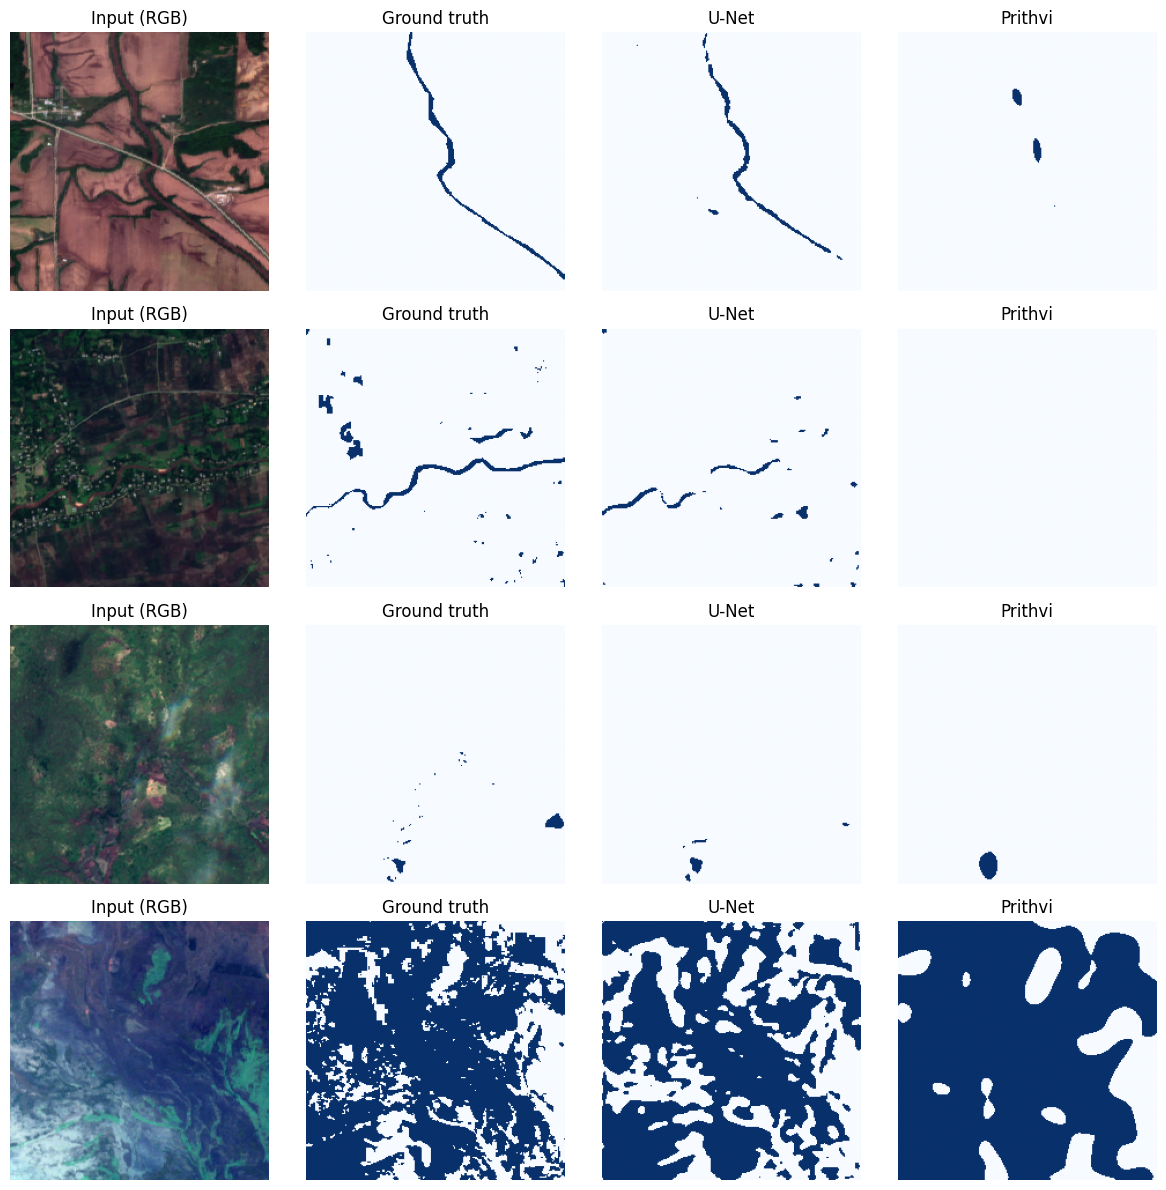

Saved: /kaggle/working/sample_predictions.png


In [12]:
def visualize_predictions(models_by_label, dataset, n=4, save_path="/kaggle/working/sample_predictions.png"):
    for m in models_by_label.values():
        m.eval()
    n_cols = 2 + len(models_by_label)  # input, ground truth, one column per model
    fig, axes = plt.subplots(n, n_cols, figsize=(3 * n_cols, 3 * n))
    idxs = random.sample(range(len(dataset)), n)
    with torch.no_grad():
        for row, idx in enumerate(idxs):
            image, mask = dataset[idx]

            rgb = image[[2, 1, 0], :, :].permute(1, 2, 0).numpy()  # RGB from red/green/blue bands (indices 2,1,0)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

            axes[row, 0].imshow(rgb); axes[row, 0].set_title("Input (RGB)"); axes[row, 0].axis("off")
            axes[row, 1].imshow(mask.numpy(), cmap="Blues"); axes[row, 1].set_title("Ground truth"); axes[row, 1].axis("off")

            for col, (label, m) in enumerate(models_by_label.items(), start=2):
                pred = m(image.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze(0).cpu().numpy()
                axes[row, col].imshow(pred, cmap="Blues"); axes[row, col].set_title(label); axes[row, col].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

# test_ds_vis (single center-crop per image) rather than test_ds_full (which returns full 512x512
# images the *_model.forward() calls here don't tile -- tiled inference is what section 7 uses for
# the real metrics; this visualization is illustrative, single-crop is fine for that).
visualize_predictions({"U-Net": baseline_model, "Prithvi": model}, test_ds_vis)


## 9. Export artifacts

Download these three files (plus `sample_predictions.png`) from Kaggle's output panel before your session ends -- they're what the backend (`IMPLEMENTATION_PLAN.md`, section 5) needs.


In [13]:
# Pick whichever model actually scored higher on the held-out test set -- not hardcoded.
candidates = {"unet_baseline": (baseline_metrics, "/kaggle/working/best_unet_baseline.pt"),
              "prithvi_finetune": (prithvi_metrics, "/kaggle/working/best_prithvi_finetune.pt")}
best_tag = max(candidates, key=lambda t: candidates[t][0]["mean_iou"])
FINAL_METRICS, FINAL_MODEL_PATH = candidates[best_tag]
print(f"Best model: {best_tag} (mean_iou={FINAL_METRICS['mean_iou']:.4f}) -- exporting this one as flood_segmentation_model.pt")

import shutil
shutil.copy(FINAL_MODEL_PATH, "/kaggle/working/flood_segmentation_model.pt")

model_config = {
    "bands": CONFIG["bands"],
    "chip_size": CONFIG["chip_size"],
    "num_classes": CONFIG["num_classes"],
    "normalization": {
        "method": "per-band (x - mean) / std, computed once over the training split (see section 4)",
        "mean": BAND_MEAN,
        "std": BAND_STD,
    },
    "architecture": FINAL_METRICS["tag"],
}
with open("/kaggle/working/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# Save both models' metrics, not just the winner's -- useful for the README's "X mIoU vs Y mIoU" comparison.
all_metrics = {"selected": FINAL_METRICS["tag"], "unet_baseline": baseline_metrics, "prithvi_finetune": prithvi_metrics}
with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

# Zip everything into one file so there's a single download instead of four separate ones.
import zipfile

ARTIFACT_FILES = [
    "/kaggle/working/flood_segmentation_model.pt",
    "/kaggle/working/model_config.json",
    "/kaggle/working/metrics.json",
    "/kaggle/working/sample_predictions.png",
]
ZIP_PATH = "/kaggle/working/flood_segmentation_artifacts.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in ARTIFACT_FILES:
        if os.path.exists(path):
            zf.write(path, arcname=os.path.basename(path))
        else:
            print(f"Warning: {path} not found, skipping (run the earlier cells that produce it).")

print(f"\nZipped into {ZIP_PATH} -- download this one file from Kaggle's output panel and")
print("extract flood_segmentation_model.pt, model_config.json, metrics.json into models/ in the project.")

Best model: unet_baseline (mean_iou=0.8905) -- exporting this one as flood_segmentation_model.pt

Zipped into /kaggle/working/flood_segmentation_artifacts.zip -- download this one file from Kaggle's output panel and
extract flood_segmentation_model.pt, model_config.json, metrics.json into models/ in the project.
